In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('train.csv')

In [3]:
train.head().T

,0,1,2,3,4
PassengerId,1,2,3,4,5
Survived,0,1,1,1,0
Pclass,3,1,3,1,3
Name,"Braund, Mr. Owen Harris","Cumings, Mrs. John Bradley (Florence Briggs Th...","Heikkinen, Miss. Laina","Futrelle, Mrs. Jacques Heath (Lily May Peel)","Allen, Mr. William Henry"
Sex,male,female,female,female,male
Age,22.0,38.0,26.0,35.0,35.0
SibSp,1,1,0,1,0
Parch,0,0,0,0,0
Ticket,A/5 21171,PC 17599,STON/O2. 3101282,113803,373450
Fare,7.25,71.2833,7.925,53.1,8.05


In [4]:
train.drop(columns=['PassengerId', 'Name', 'Ticket'], inplace=True)

In [5]:
train.head().T

,0,1,2,3,4
Survived,0,1,1,1,0
Pclass,3,1,3,1,3
Sex,male,female,female,female,male
Age,22.0,38.0,26.0,35.0,35.0
SibSp,1,1,0,1,0
Parch,0,0,0,0,0
Fare,7.25,71.2833,7.925,53.1,8.05
Cabin,NaN,C85,NaN,C123,NaN
Embarked,S,C,S,S,S


In [6]:
dtypes = train.dtypes
n_unique = train.nunique()
pd.DataFrame({'Dtypes': dtypes, 'num_unique': n_unique}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,int64,int64,object,float64,int64,int64,float64,object,object
num_unique,2,3,2,88,7,7,248,147,3


In [7]:
from check_dtype import check_dtype
check_dtype(train)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,int64,int64,object,float64,int64,int64,float64,object,object
num_unique,2,3,2,88,7,7,248,147,3


In [8]:
check_dtype(train)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
Dtypes,int64,int64,object,float64,int64,int64,float64,object,object
num_unique,2,3,2,88,7,7,248,147,3


In [9]:
cols = ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']
train[cols] = train[cols].astype('category')

In [10]:
from handle_types import handle_types
handle_types(train, cols)

In [11]:
nulls = train.isnull().sum()
ratio = nulls / train.shape[0]
pd.DataFrame({'nulls': nulls, 'ratio': ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
nulls,0.0,0.0,0.0,177.000000,0.0,0.0,0.0,687.000000,2.000000
ratio,0.0,0.0,0.0,0.198653,0.0,0.0,0.0,0.771044,0.002245


In [12]:
train.dropna(subset=['Embarked'], inplace=True)

In [13]:
train = train.drop(columns=['Cabin'],axis=1)

In [14]:
median = train['Age'].median()
train['Age'].fillna(median, inplace=True)

C:\Users\NOTEBOOK\AppData\Local\Temp\ipykernel_9036\3923942648.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(median, inplace=True)


In [15]:
nulls = train.isnull().sum()
ratio = nulls / train.shape[0]
pd.DataFrame({'nulls': nulls, 'ratio': ratio}).T

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
nulls,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [16]:
train.dtypes

Survived    category
Pclass      category
Sex         category
Age          float64
SibSp       category
Parch       category
Fare         float64
Embarked    category
dtype: object

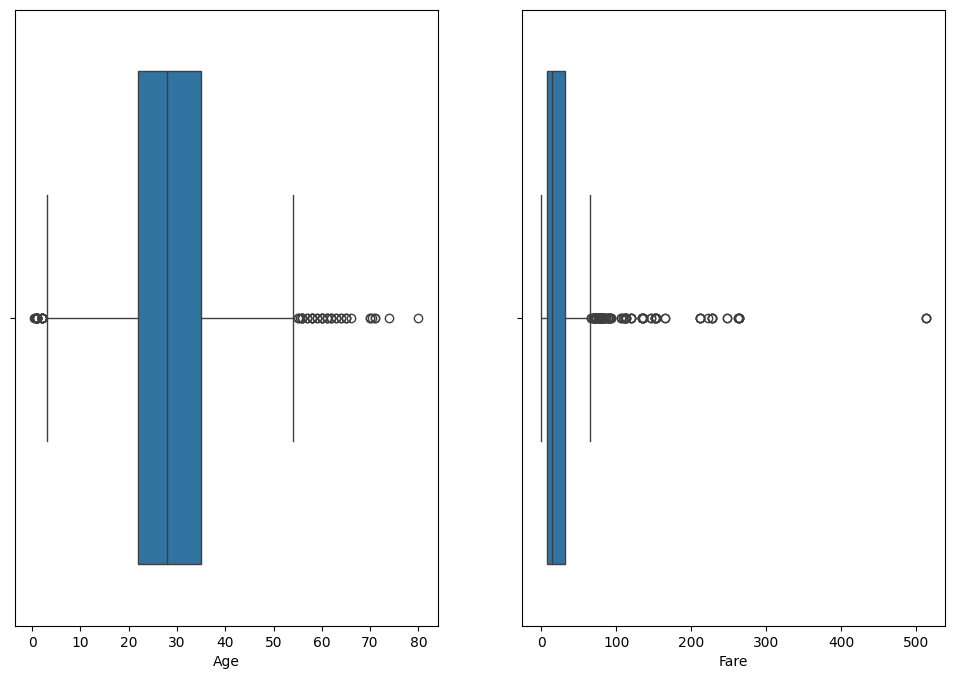

In [17]:
num_cols = train.select_dtypes('number').columns
plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.boxplot(train[col], orient='h')

In [18]:
for col in num_cols:
    q1 = train[col].quantile(0.25)
    q3 = train[col].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    lower_outlier = train[train[col] < lower_fence]
    upper_outlier = train[train[col] > upper_fence]

    train.loc[train[col] < lower_fence, col] = lower_fence
    train.loc[train[col] > upper_fence, col] = upper_fence

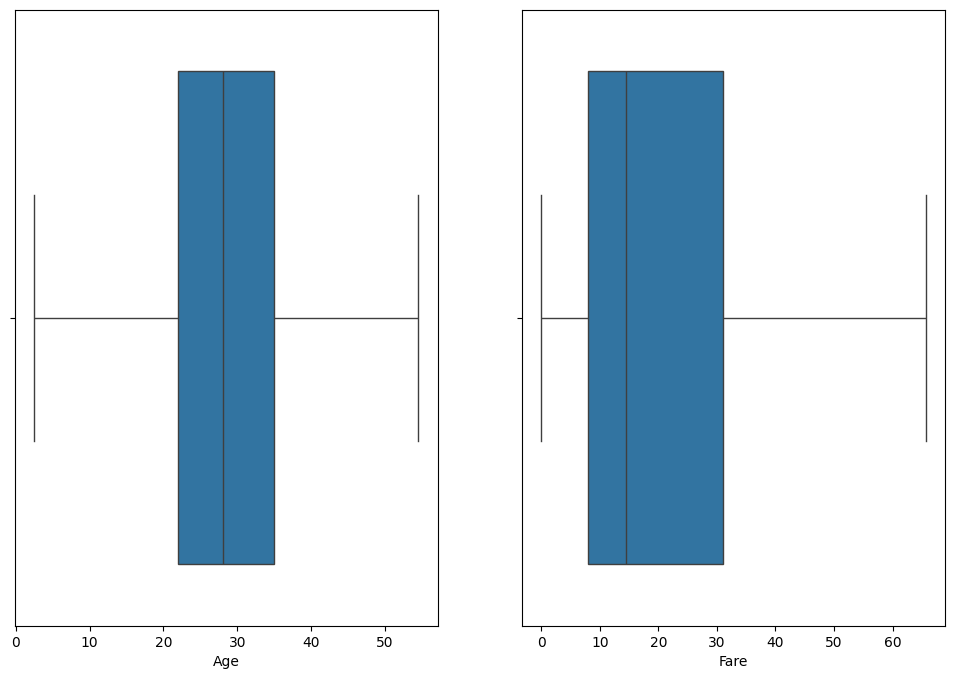

In [19]:
num_cols = train.select_dtypes('number').columns
plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.boxplot(train[col], orient='h')

In [20]:
train.duplicated().sum()

np.int64(129)

In [21]:
train.drop_duplicates(inplace=True)
train.duplicated().sum()

np.int64(0)

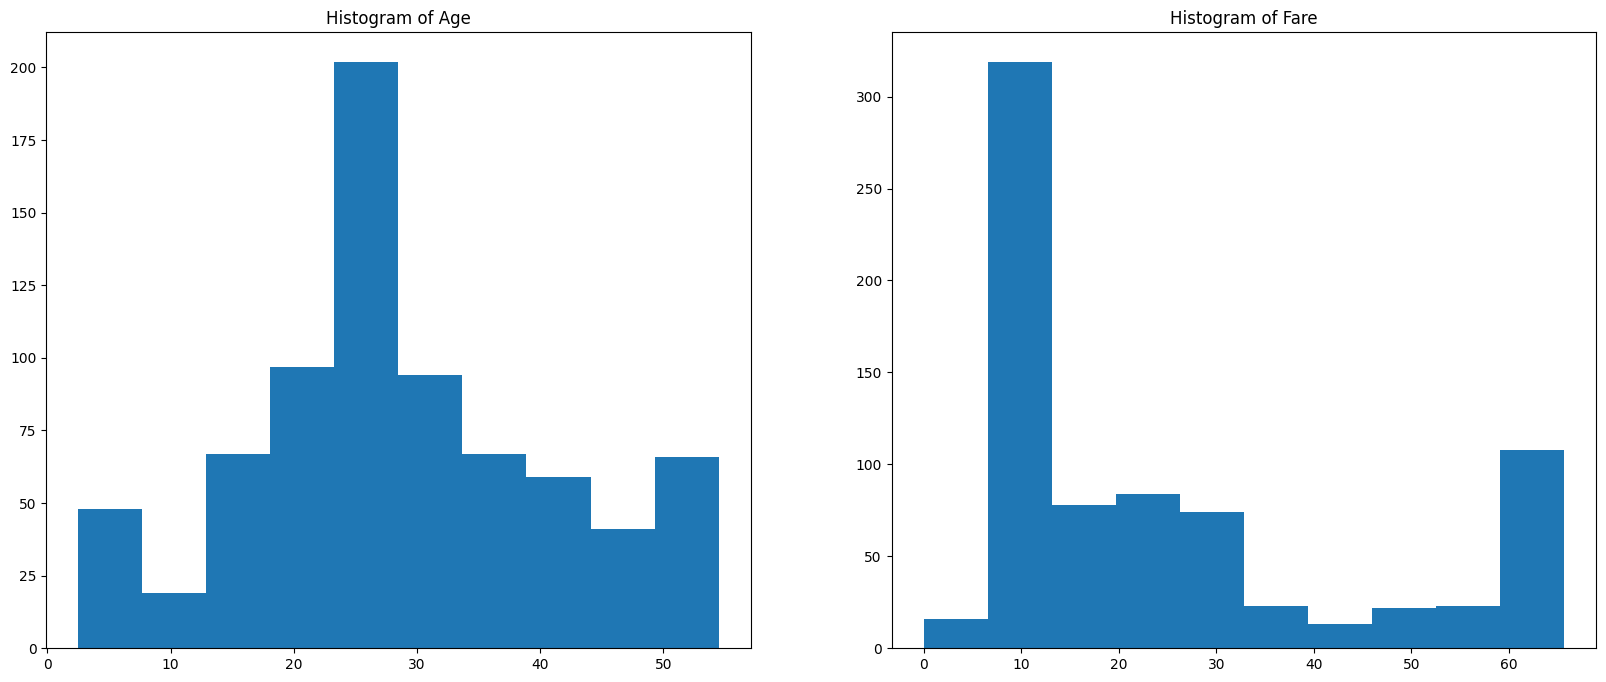

In [22]:
num_cols = train.select_dtypes('number').columns
plt.figure(figsize=(20,8))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    plt.hist(train[col])
    plt.title(f'Histogram of {col}')
plt.show()

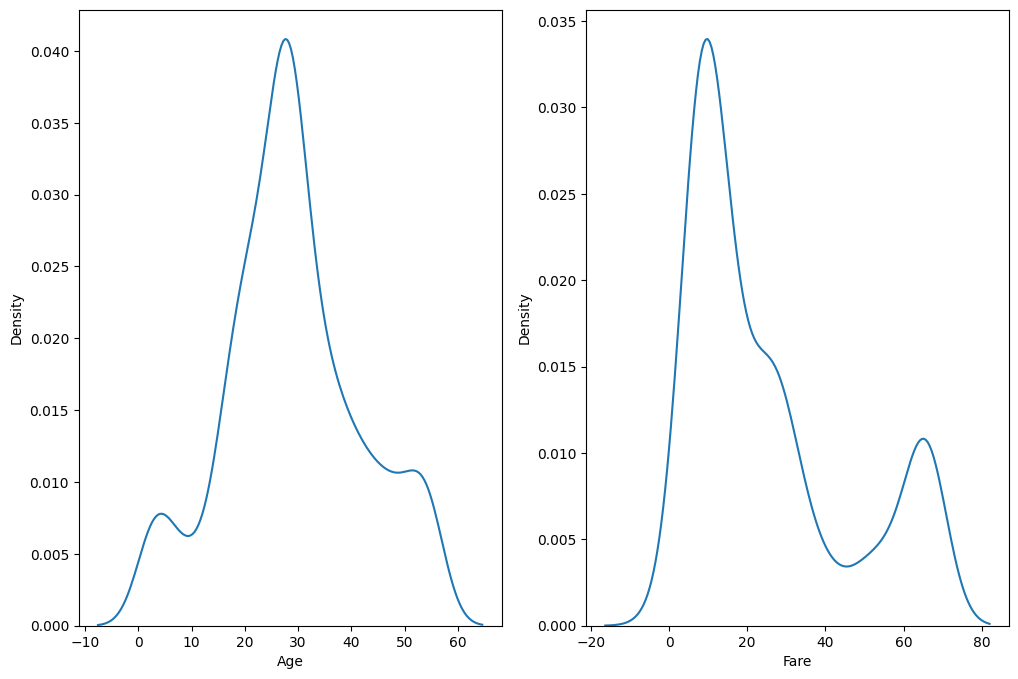

In [23]:
num_cols = train.select_dtypes('number').columns
plt.figure(figsize=(12,8))
for i, col in enumerate(num_cols):
    plt.subplot(1, 2, i+1)
    sns.kdeplot(train[col])
plt.show()

In [24]:
cat_cols = train.select_dtypes('category').columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='object')

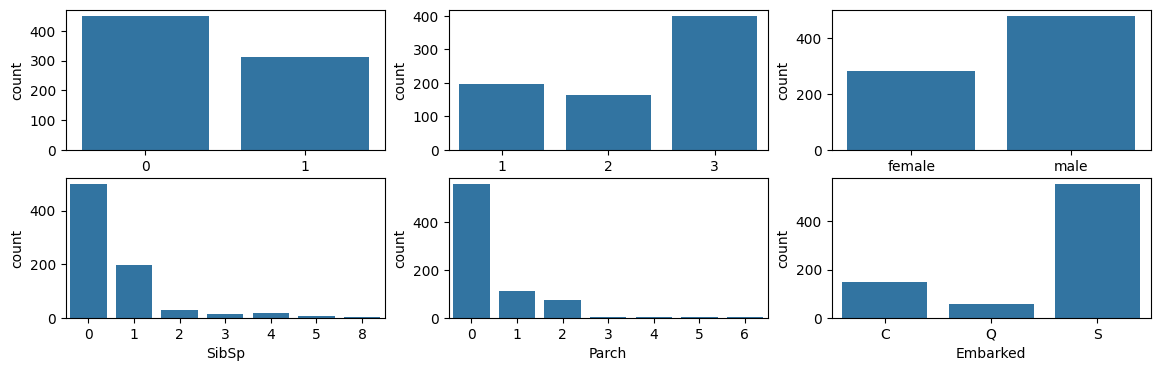

In [25]:
cat_cols = train.select_dtypes('category').columns
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x = col, data = train)
plt.show()

In [26]:
cat_cols = train.select_dtypes(include=['object', 'category']).columns
cat_cols

Index(['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'], dtype='object')

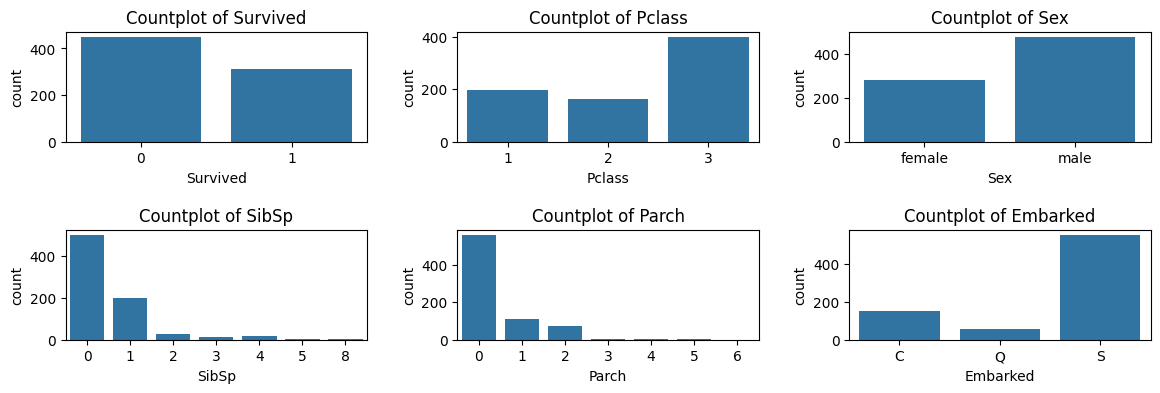

In [27]:
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x = col, data = train)
    plt.title(f'Countplot of {col}')
plt.subplots_adjust(hspace=0.8, wspace=0.3)
plt.show()

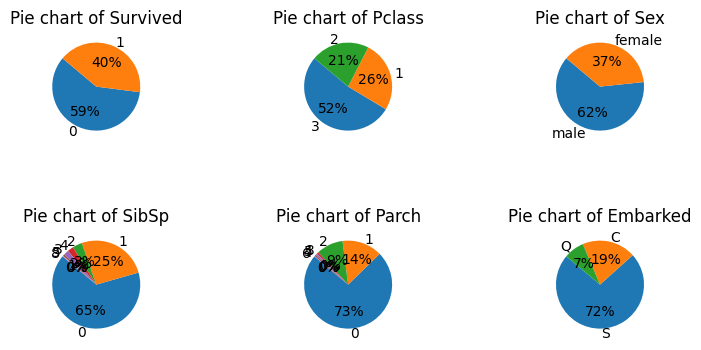

In [28]:
plt.figure(figsize=(9,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    unique = train[col].value_counts()
    count = unique.values
    category = unique.index
    plt.pie(count, labels=category, startangle=140, autopct='%1.1d%%')
    plt.title(f'Pie chart of {col}')
plt.subplots_adjust(hspace=0.8, wspace=0.3)
plt.show()

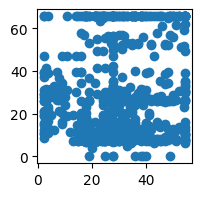

In [29]:
plt.figure(figsize=(2,2))
plt.scatter(train['Age'], train['Fare'])


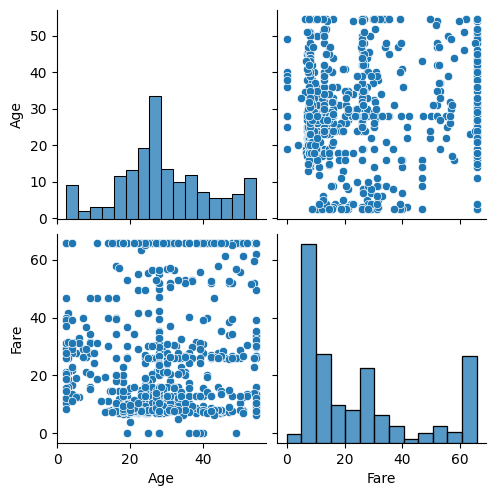

In [30]:
sns.pairplot(train)

In [31]:
train.dtypes

Survived    category
Pclass      category
Sex         category
Age          float64
SibSp       category
Parch       category
Fare         float64
Embarked    category
dtype: object

In [32]:
corr = train.select_dtypes('number').corr()
corr

,Age,Fare
Age,1.000000,0.148527
Fare,0.148527,1.000000


In [33]:
agg = train.pivot_table(index='Survived', columns ='Sex', values='Age', aggfunc=len)
agg

C:\Users\NOTEBOOK\AppData\Local\Temp\ipykernel_9036\4028307319.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  agg = train.pivot_table(index='Survived', columns ='Sex', values='Age', aggfunc=len)


Sex,female,male
Survived,,
0,76,373
1,207,104


C:\Users\NOTEBOOK\AppData\Local\Temp\ipykernel_9036\2850152276.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  agg = train.pivot_table(index='Survived', columns ='Sex', values='Age', aggfunc=len)


<module 'matplotlib.pyplot' from 'C:\\Users\\NOTEBOOK\\AppData\\Roaming\\Python\\Python312\\site-packages\\matplotlib\\pyplot.py'>

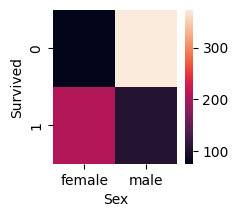

In [34]:
plt.figure(figsize=(2,2))
agg = train.pivot_table(index='Survived', columns ='Sex', values='Age', aggfunc=len)

sns.heatmap(agg)
plt

In [35]:
x = train.drop(columns='Survived')
y = train['Survived']

In [36]:
from sklearn.preprocessing import MinMaxScaler
numeric_cols = x.select_dtypes('number').columns
num_scaler = MinMaxScaler()
num_scaler.fit(x[numeric_cols])
x[numeric_cols] = num_scaler.transform(x[numeric_cols])

In [37]:
from category_encoders import OneHotEncoder
cat_cols = x.select_dtypes('category').columns
encoder = OneHotEncoder(cols = cat_cols, drop_invariant=True)
x = encoder.fit_transform(x)

In [38]:
x

,Pclass_1,Pclass_2,Pclass_3,Sex_1,Sex_2,Age,SibSp_1,SibSp_2,SibSp_3,SibSp_4,...,Parch_2,Parch_3,Parch_4,Parch_5,Parch_6,Parch_7,Fare,Embarked_1,Embarked_2,Embarked_3
0,1,0,0,1,0,0.375000,1,0,0,0,...,0,0,0,0,0,0,0.110424,1,0,0
1,0,1,0,0,1,0.682692,1,0,0,0,...,0,0,0,0,0,0,1.000000,0,1,0
2,1,0,0,0,1,0.451923,0,1,0,0,...,0,0,0,0,0,0,0.120704,1,0,0
3,0,1,0,0,1,0.625000,1,0,0,0,...,0,0,0,0,0,0,0.808757,1,0,0
4,1,0,0,1,0,0.625000,0,1,0,0,...,0,0,0,0,0,0,0.122608,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,1,0,0,0,1,0.701923,0,1,0,0,...,0,0,1,0,0,0,0.443598,0,0,1
887,0,1,0,0,1,0.317308,0,1,0,0,...,0,0,0,0,0,0,0.456925,1,0,0
888,1,0,0,0,1,0.490385,1,0,0,0,...,0,1,0,0,0,0,0.357163,1,0,0
889,0,1,0,1,0,0.451923,0,1,0,0,...,0,0,0,0,0,0,0.456925,0,1,0


In [39]:
import plotly.express as px
import plotly.graph_objects as go

In [ ]:
fig = px.pie(train, names='Survived',
       title = '<b>Survived distribution</b>',
       color_discrete_sequence=px.colors.qualitative.Pastel,
       hole=0.4)
fig.show()

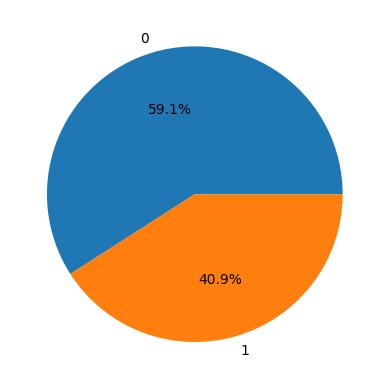

In [42]:
counts = train['Survived'].value_counts()
plt.pie(counts.values, labels=counts.index, autopct='%1.1f%%')
plt.show()

In [44]:
fig = px.pie(train, names='Survived',
       title = '<b>Survived distribution</b>',
       color_discrete_sequence=px.colors.qualitative.Pastel,
       hole=0.4)
fig.show()

In [45]:
def pie_plot(df, column):
    fig = px.pie(df, names=column,
           title = f'<b>{column} distribution</b>',
           color_discrete_sequence=px.colors.qualitative.Pastel,
           hole=0.4)
    fig.show()

column = input("Enter column name: ")
pie_plot(train, column)

In [51]:
fig = px.pie(train, names='Survived',
       title = '<b>Survived distribution</b>',
       color_discrete_map={0:'Blue', 1:'Red'},
       category_orders={'Survived':[0,1]},
       hole=0.4)
fig.show()

In [54]:
fig = px.pie(train, names='Survived',
       title = '<b>Survived distribution</b>',
       color_discrete_sequence=px.colors.qualitative.Pastel,
       hole=0.4)
fig.update_layout(annotations = [dict(text='Survived', font_size=20, x=0.5, y=0.5, showarrow=False)])
fig.show()

In [59]:
fig = px.histogram(train, x='Survived', color ='Sex', title='<b>Survived based on gender</b>', barmode='group')
fig.update_layout(width=700, height=500, bargap=0.5)

In [68]:
import plotly.subplots as sp
import plotly.graph_objects as go
fig = sp.make_subplots(rows=1, cols=len(num_cols), subplot_titles=num_cols)
for i, col in enumerate(num_cols):
    fig.add_trace(
        go.Histogram(x=train[col], name=col,marker = dict(line=dict(color='blue', width=1))),
        row=1,
        col=i+1)
fig.show()